In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import fourier_shift, gaussian_filter
from skimage import data

from metrics import frc, fsc, fouriercorr_plot

### Test with 2D images of random values
Since the values are random, there must not be an important correlation

In [2]:
np.random.seed(1) 
img1 = np.random.randn(301,301)
img2 = np.random.randn(301,301)

FRC, T, fn = frc(img1, img2, apod_width = 10, ringthick=1, threshold ='onebit')

Computing FRC using 1-bit threshold
Calculating the correlation...
Done


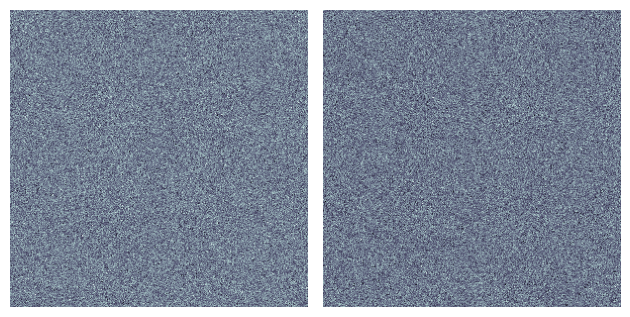

In [3]:
fig0 = plt.figure()
ax1 = fig0.add_subplot(121)
ax1.imshow(img1, cmap='bone')
ax1.set_axis_off()
ax2 = fig0.add_subplot(122)
ax2.imshow(img2, cmap='bone')
ax2.set_axis_off()
plt.tight_layout()

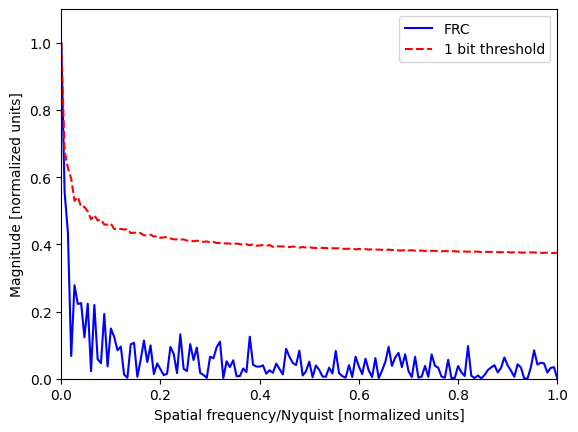

<Figure size 640x480 with 0 Axes>

In [4]:
fouriercorr_plot(FRC, T, fn, 'frc_random2D.png')

### Test with 2D images: cameraman

In [5]:
testimg = data.camera()
img1 = testimg
img2 = gaussian_filter(testimg,sigma=2)

In [6]:
# offset image
shift = (-12.4,13.32) # Shift the image on purpose to test the alignment routine
img2 = np.fft.ifft2(fourier_shift(np.fft.fft2(img2),shift)).real

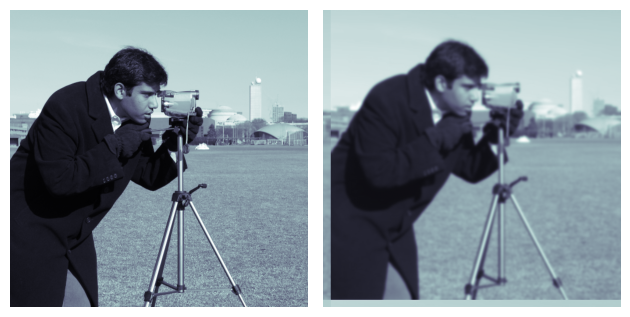

In [7]:
fig1 = plt.figure(1)
ax1 = fig1.add_subplot(121)
ax1.imshow(img1, cmap='bone')
ax1.set_axis_off()
ax2 = fig1.add_subplot(122)
ax2.imshow(img2, cmap='bone')
ax2.set_axis_off()
plt.tight_layout()

In [8]:
FRC, T, fn = frc(img1, img2, apod_width = 100, ringthick=2, threshold ='onebit')

Computing FRC using 1-bit threshold
Calculating the correlation...
Done


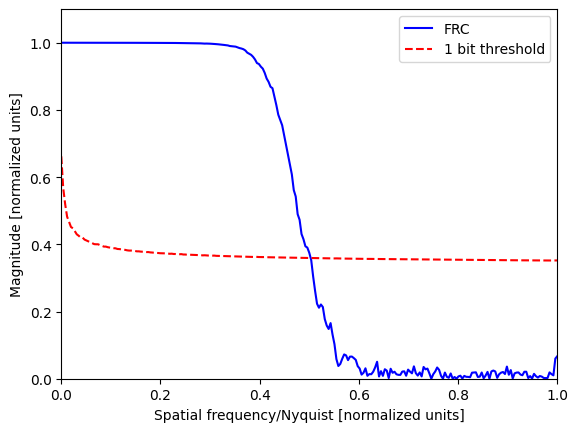

<Figure size 640x480 with 0 Axes>

In [9]:
fouriercorr_plot(FRC, T, fn, 'frc_test1.png')

### Another 2D image

In [10]:
testimg = data.chelsea().mean(axis=2)
img1 = testimg
img2 = testimg + 0.5*np.max(testimg)*np.random.rand(testimg.shape[0],testimg.shape[1])

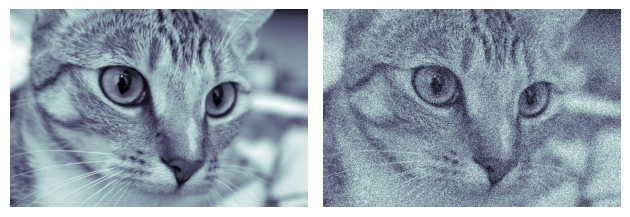

In [11]:
fig2 = plt.figure(2)
ax1 = fig2.add_subplot(121)
ax1.imshow(img1, cmap='bone')
ax1.set_axis_off()
ax2 = fig2.add_subplot(122)
ax2.imshow(img2, cmap='bone')
ax2.set_axis_off()
plt.tight_layout()

In [12]:
FRC, T, fn = frc(img1, img2, apod_width = 100, ringthick=6, threshold ='onebit')

Computing FRC using 1-bit threshold
Calculating the correlation...
Done


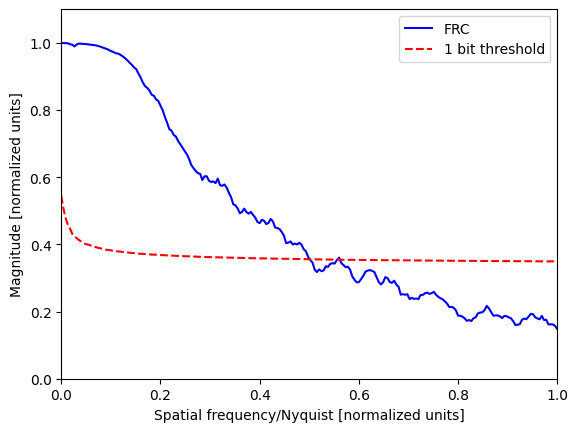

<Figure size 640x480 with 0 Axes>

In [13]:
fouriercorr_plot(FRC, T, fn, 'frc_test2.png')

### Test with random 3D images

In [14]:
# 3D test with random number
np.random.seed(1) 
img1 = np.random.randn(110,120,100)
img2 = np.random.randn(110,120,100)

In [17]:
# please, note that we use fsc instead of frc here
FSC, T, fn = fsc(img1, img2, apod_width = 100, ringthick=2, threshold ='onebit',apod_type='transverse')

Apodization in 3D. This takes time and memory...
Computing FRC using 1-bit threshold
Calculating the correlation...
Done


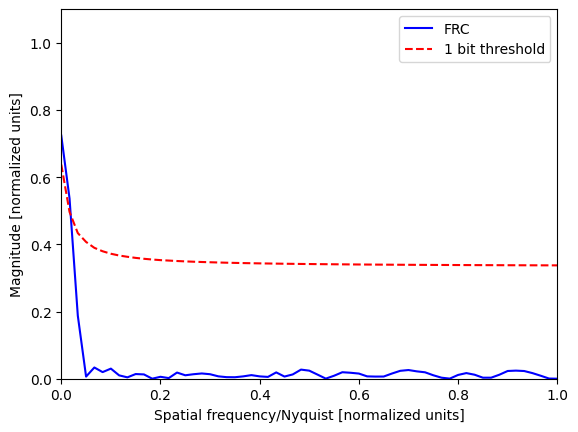

<Figure size 640x480 with 0 Axes>

In [18]:
fouriercorr_plot(FSC, T, fn, 'fsc_test1.png')